<a href="https://colab.research.google.com/github/juborduchi/governanca-digital_mre/blob/main/notebooks/analise_nota_mre.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importação de bibliotecas

In [37]:
import os
import json
import pandas as pd
import glob

!pip install wordcloud -q


# Acesso ao drive

In [17]:
from google.colab import drive
drive.mount('/content/gdrive', force_remount=True)

Mounted at /content/gdrive


# Organização dos JSONs no DataFrame

In [18]:
def consolidar_jsons_aninhados(caminho_diretorio):
    lista_dataframes = []

    # Listar arquivos
    arquivos = [f for f in os.listdir(caminho_diretorio) if f.endswith('.json')]

    if not arquivos:
        print("Nenhum arquivo JSON encontrado.")
        return None

    for arquivo in arquivos:
        caminho_completo = os.path.join(caminho_diretorio, arquivo)

        try:
            with open(caminho_completo, 'r', encoding='utf-8') as f:
                dados = json.load(f)

                # EXPLICAÇÃO TÉCNICA:
                # Se o seu JSON tem o formato {'_default': {'0': {...}, '1': {...}}},
                # precisamos extrair os valores da chave '_default'.
                if '_default' in dados:
                    # Transformamos os valores de '_default' em uma lista e normalizamos
                    conteudo = list(dados['_default'].values())
                    df_temp = pd.json_normalize(conteudo)
                else:
                    # Caso o JSON seja uma lista direta ou outra estrutura
                    df_temp = pd.json_normalize(dados)

                lista_dataframes.append(df_temp)
        except Exception as e:
            print(f"Erro ao processar {arquivo}: {e}")

    # Concatenar todos os arquivos processados
    df_final = pd.concat(lista_dataframes, ignore_index=True)

    # Limpeza de listas: Se os dados vierem como ['Brasil'], removemos os parênteses
    # Aplicamos uma função que extrai o primeiro elemento se o dado for uma lista
    df_final = df_final.applymap(lambda x: x[0] if isinstance(x, list) and len(x) > 0 else x)

    return df_final

# --- CONFIGURAÇÃO DO CAMINHO ---
caminho_pasta = '/content/gdrive/MyDrive/Colab_Notebooks/pibic-2025-2026/json-notas/'

# Execução
df = consolidar_jsons_aninhados(caminho_pasta)

# Exibição do resultado
if df is not None:
    print("DataFrame Organizado:")
    display(df.head())

DataFrame Organizado:


/tmp/ipykernel_21064/1430405251.py:38: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_final = df_final.applymap(lambda x: x[0] if isinstance(x, list) and len(x) > 0 else x)


,tipo_dado,pais,origem,sigla,classificado,categoria,autoria,titulo,subtitulo,data,...,nome_arquivo,dir_arquivo,dir_base,codigo_bd,dir_bd,nome_arq_bd,env_dir_bd,extra_01,extra_02,extra_03
0,aberto,Brasil,ministerio das relações exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_NOTAS_IMPRENSA,noticias institucionais,[],NA,Calendário de eventos entre 11 e 19 de janeiro...,,10/01/2014,...,NA,NA,/hdvm12,bd/003/001/001/001/002/001,/json/,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_NOTAS_IMPRENSA-...,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_NOTAS_IMPRENSA,NA,NA,NA
1,aberto,Brasil,ministerio das relações exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_NOTAS_IMPRENSA,noticias institucionais,[],NA,Conferência Internacional sobre Síria (Genebra...,,08/01/2014,...,NA,NA,/hdvm12,bd/003/001/001/001/002/001,/json/,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_NOTAS_IMPRENSA-...,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_NOTAS_IMPRENSA,NA,NA,NA
2,aberto,Brasil,ministerio das relações exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_NOTAS_IMPRENSA,noticias institucionais,[],NA,Calendário de eventos entre 4 de janeiro e 12 ...,,03/01/2014,...,NA,NA,/hdvm12,bd/003/001/001/001/002/001,/json/,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_NOTAS_IMPRENSA-...,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_NOTAS_IMPRENSA,NA,NA,NA
3,aberto,Brasil,ministerio das relações exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_NOTAS_IMPRENSA,noticias institucionais,[],NA,Atentados no Líbano,,02/01/2014,...,NA,NA,/hdvm12,bd/003/001/001/001/002/001,/json/,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_NOTAS_IMPRENSA-...,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_NOTAS_IMPRENSA,NA,NA,NA
4,aberto,Brasil,ministerio das relações exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_NOTAS_IMPRENSA,noticias institucionais,[],NA,Calendário de eventos entre 1º e 9 de fevereir...,,31/01/2014,...,NA,NA,/hdvm12,bd/003/001/001/001/002/001,/json/,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_NOTAS_IMPRENSA-...,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_NOTAS_IMPRENSA,NA,NA,NA


In [19]:
df.columns

Index(['tipo_dado', 'pais', 'origem', 'sigla', 'classificado', 'categoria',
       'autoria', 'titulo', 'subtitulo', 'data', 'horario', 'datatime',
       'data_atualizado', 'horario_atualizado', 'link', 'link_archive',
       'data_archive', 'horario_archive', 'local', 'tags', 'paragrafos',
       'imagens', 'nome_arquivo', 'dir_arquivo', 'dir_base', 'codigo_bd',
       'dir_bd', 'nome_arq_bd', 'env_dir_bd', 'extra_01', 'extra_02',
       'extra_03'],
      dtype='object')

# Preparação dos dados para análise

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

# 1.1 — Converter data para datetime (dayfirst pq é formato brasileiro: dd/mm/aaaa)
df['data_dt'] = pd.to_datetime(df['data'], dayfirst=True, errors='coerce')

# 1.2 — Juntar os parágrafos (que são listas) em um único texto
df['texto'] = df['paragrafos'].apply(lambda lista: ' '.join(lista) if isinstance(lista, list) else str(lista))

# 1.3 — Coluna com tudo junto e em minúsculas (facilita buscas)
df['texto_completo'] = (df['titulo'].fillna('') + ' ' + df['texto']).str.lower()

# 1.4 — Extrair a hora como número inteiro (de "19h20" tira o 19)
df['hora_int'] = df['horario'].str.extract(r'(\d{1,2})').astype(float)

# 1.5 — Colunas auxiliares de tempo
df['ano_mes'] = df['data_dt'].dt.to_period('M')
df['dia_semana'] = df['data_dt'].dt.day_name()
df['tamanho_texto'] = df['texto'].str.len()
df['qtd_paragrafos'] = df['paragrafos'].apply(lambda x: len(x) if isinstance(x, list) else 0)

print(f"Total de notas: {len(df)}")
print(f"Período: de {df['data_dt'].min().date()} até {df['data_dt'].max().date()}")
df[['titulo', 'data_dt', 'hora_int', 'qtd_paragrafos', 'tamanho_texto']].head()

Total de notas: 5169
Período: de 2014-01-02 até 2025-12-31


,titulo,data_dt,hora_int,qtd_paragrafos,tamanho_texto
0,Calendário de eventos entre 11 e 19 de janeiro...,2014-01-10,17.0,0,244
1,Conferência Internacional sobre Síria (Genebra...,2014-01-08,17.0,0,132
2,Calendário de eventos entre 4 de janeiro e 12 ...,2014-01-03,18.0,0,310
3,Atentados no Líbano,2014-01-02,10.0,0,80
4,Calendário de eventos entre 1º e 9 de fevereir...,2014-01-31,18.0,0,85


In [21]:
df_customizado = df[["autoria","titulo",
       "data_atualizado", "horario_atualizado", "link", "paragrafos", "texto_completo","data_dt", "hora_int", "qtd_paragrafos", "tamanho_texto"]]
df_customizado

,autoria,titulo,data_atualizado,horario_atualizado,link,paragrafos,texto_completo,data_dt,hora_int,qtd_paragrafos,tamanho_texto
0,NA,Calendário de eventos entre 11 e 19 de janeiro...,31/10/2022,17h22,https://www.gov.br/mre/pt-br/canais_atendiment...,"9 a 18/JAN – Nova York, EUA. Convenção Anual d...",calendário de eventos entre 11 e 19 de janeiro...,2014-01-10,17.0,0,244
1,NA,Conferência Internacional sobre Síria (Genebra...,31/10/2022,17h21,https://www.gov.br/mre/pt-br/canais_atendiment...,Os profissionais de imprensa interessados em p...,conferência internacional sobre síria (genebra...,2014-01-08,17.0,0,132
2,NA,Calendário de eventos entre 4 de janeiro e 12 ...,31/10/2022,17h21,https://www.gov.br/mre/pt-br/canais_atendiment...,4 a 11/JAN – Singapura. Visita a Singapura do ...,calendário de eventos entre 4 de janeiro e 12 ...,2014-01-03,18.0,0,310
3,NA,Atentados no Líbano,31/10/2022,17h21,https://www.gov.br/mre/pt-br/canais_atendiment...,O Governo brasileiro condena a série recente d...,atentados no líbano o governo brasileiro conde...,2014-01-02,10.0,0,80
4,NA,Calendário de eventos entre 1º e 9 de fevereir...,31/10/2022,17h22,https://www.gov.br/mre/pt-br/canais_atendiment...,"1º e 2/FEV – Melbourne, Austrália. Festival Mu...",calendário de eventos entre 1º e 9 de fevereir...,2014-01-31,18.0,0,85
...,...,...,...,...,...,...,...,...,...,...,...
5164,Ministério das Relações Exteriores,Acordo entre o Reino do Bahrein e o Estado de ...,NA,NA,https://www.gov.br/mre/pt-br/canais_atendiment...,O governo brasileiro recebeu com satisfação ...,acordo entre o reino do bahrein e o estado de ...,2020-09-12,18.0,0,257
5165,Ministério das Relações Exteriores,Declaração Conjunta sobre o Comércio de Etanol...,NA,NA,https://www.gov.br/mre/pt-br/canais_atendiment...,Brasil e Estados Unidos realizaram consultas s...,declaração conjunta sobre o comércio de etanol...,2020-09-11,23.0,0,890
5166,Ministério das Relações Exteriores,Representantes do regime ilegítimo da Venezuel...,NA,NA,https://www.gov.br/mre/pt-br/canais_atendiment...,"Na data de hoje, 4 de setembro de 2020, o Gove...",representantes do regime ilegítimo da venezuel...,2020-09-04,20.0,0,210
5167,Ministério das Relações Exteriores,Embargo indevido do Governo das Filipinas à ca...,NA,NA,https://www.gov.br/mre/pt-br/canais_atendiment...,"O governo da República das Filipinas impôs, ...",embargo indevido do governo das filipinas à ca...,2020-09-04,18.0,0,239


In [22]:
df.shape

(5169, 40)

In [23]:
df_customizado.describe(include="all")

,autoria,titulo,data_atualizado,horario_atualizado,link,paragrafos,texto_completo,data_dt,hora_int,qtd_paragrafos,tamanho_texto
count,5169,5169,5169,5169,5169,5169,5169,5169,5169.000000,5169.0,5169.000000
unique,2,4922,659,669,5169,4975,5156,NaN,NaN,NaN,NaN
top,Ministério das Relações Exteriores,Situação em Israel e na Palestina. Repatriação...,NA,NA,https://www.gov.br/mre/pt-br/canais_atendiment...,.,comunicado do grupo de lima tradução não oficial,NaN,NaN,NaN,NaN
freq,2873,14,2942,2942,1,26,3,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020-02-29 02:14:33.360418048,16.212033,0.0,327.447088
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014-01-02 00:00:00,0.000000,0.0,1.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016-08-25 00:00:00,13.000000,0.0,172.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019-06-26 00:00:00,17.000000,0.0,245.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023-12-08 00:00:00,20.000000,0.0,359.000000
max,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-12-31 00:00:00,23.000000,0.0,57109.000000


In [24]:
notas_por_dia = df['data_dt'].value_counts().sort_index()

display(notas_por_dia)

,count
data_dt,
2014-01-02,1
2014-01-03,1
2014-01-08,1
2014-01-10,2
2014-01-14,3
...,...
2025-12-22,2
2025-12-24,1
2025-12-26,1


## Verificando duplicatas

In [25]:
# Duplicatas por link (cada nota deveria ter um link único)
print("Duplicatas por link:", df.duplicated(subset=['link']).sum())

# Duplicatas por título
print("Duplicatas por título:", df.duplicated(subset=['titulo']).sum())




Duplicatas por link: 0
Duplicatas por título: 247


In [26]:

print("\n--- Registros com Títulos Duplicados ---")
duplicadas_titulo = df[df.duplicated(subset=['titulo'], keep=False)]
print(f"Total de linhas envolvidas em duplicatas de título: {len(duplicadas_titulo)}")
display(duplicadas_titulo.sort_values(by='titulo'))


--- Registros com Títulos Duplicados ---
Total de linhas envolvidas em duplicatas de título: 366


,tipo_dado,pais,origem,sigla,classificado,categoria,autoria,titulo,subtitulo,data,...,extra_02,extra_03,data_dt,texto,texto_completo,hora_int,ano_mes,dia_semana,tamanho_texto,qtd_paragrafos
812,aberto,Brasil,ministerio das relações exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_NOTAS_IMPRENSA,noticias institucionais,[],NA,21ª Conferência das Partes da Convenção-Quadro...,,09/11/2015,...,NA,NA,2015-11-09,"Foi antecipado, para hoje, dia 9 de novembro, ...",21ª conferência das partes da convenção-quadro...,13.0,2015-11,Monday,362,0
760,aberto,Brasil,ministerio das relações exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_NOTAS_IMPRENSA,noticias institucionais,[],NA,21ª Conferência das Partes da Convenção-Quadro...,,27/10/2015,...,NA,NA,2015-10-27,Encerra-se no próximo dia 20 de novembro o pra...,21ª conferência das partes da convenção-quadro...,18.0,2015-10,Tuesday,326,0
4090,aberto,Brasil,ministerio das relações exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_NOTAS_IMPRENSA,noticias institucionais,[],Ministério das Relações Exteriores,Abertura de mercado no Peru - Nota Conjunta MR...,,17/04/2025,...,NA,NA,2025-04-17,O governo brasileiro e o governo peruano concl...,abertura de mercado no peru - nota conjunta mr...,17.0,2025-04,Thursday,165,0
4100,aberto,Brasil,ministerio das relações exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_NOTAS_IMPRENSA,noticias institucionais,[],Ministério das Relações Exteriores,Abertura de mercado no Peru - Nota Conjunta MR...,,08/04/2025,...,NA,NA,2025-04-08,O governo brasileiro e o governo peruano concl...,abertura de mercado no peru - nota conjunta mr...,13.0,2025-04,Tuesday,189,0
4651,aberto,Brasil,ministerio das relações exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_NOTAS_IMPRENSA,noticias institucionais,[],Ministério das Relações Exteriores,Acidente aéreo na Indonésia,,29/10/2018,...,NA,NA,2018-10-29,O governo brasileiro manifesta seu profundo pe...,acidente aéreo na indonésia o governo brasilei...,22.0,2018-10,Monday,223,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
421,aberto,Brasil,ministerio das relações exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_NOTAS_IMPRENSA,noticias institucionais,[],NA,Visita da Comissão de Chanceleres da UNASUL à ...,,05/03/2015,...,NA,NA,2015-03-05,"O Ministro das Relações Exteriores, Embaixador...",visita da comissão de chanceleres da unasul à ...,18.0,2015-03,Thursday,344,0
3745,aberto,Brasil,ministerio das relações exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_NOTAS_IMPRENSA,noticias institucionais,[],Ministério das Relações Exteriores,Visita do Ministro Mauro Vieira a Omã – 8 de s...,,07/09/2024,...,NA,NA,2024-09-07,"O Ministro das Relações Exteriores, Mauro Vi...",visita do ministro mauro vieira a omã – 8 de s...,15.0,2024-09,Saturday,519,0
3744,aberto,Brasil,ministerio das relações exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_NOTAS_IMPRENSA,noticias institucionais,[],Ministério das Relações Exteriores,Visita do Ministro Mauro Vieira a Omã – 8 de s...,,08/09/2024,...,NA,NA,2024-09-08,"O Ministro das Relações Exteriores, Mauro Vi...",visita do ministro mauro vieira a omã – 8 de s...,8.0,2024-09,Sunday,519,0
1606,aberto,Brasil,ministerio das relações exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_NOTAS_IMPRENSA,noticias institucionais,[],NA,Visita do ministro Aloysio Nunes Ferreira ao C...,,10/04/2017,...,NA,NA,2017-04-10,"O ministro Aloysio Nunes Ferreira realiza, nos...",visita do ministro aloysio nunes ferreira ao c...,16.0,2017-04,Monday,107,0


### Verificando duplicata por titulo

In [27]:
# Supondo que seu DataFrame seja 'df'
coluna_busca = 'titulo' # ou 'link'

# 1. Contagem de "Excedentes" (O que o seu .sum() estava fazendo)
total_excedentes = df.duplicated(subset=[coluna_busca], keep='first').sum()

# 2. DataFrame de Visualização (Todas as ocorrências)
df_todas_duplicatas = df[df.duplicated(subset=[coluna_busca], keep=False)]
total_na_visualizacao = len(df_todas_duplicatas)

print(f"--- Relatório de Consistência: {coluna_busca} ---")
print(f"Quantidade de cópias excedentes (sum): {total_excedentes}")
print(f"Total de linhas que são duplicatas entre si: {total_na_visualizacao}")
print("-" * 40)

# 3. Exibição Estruturada
# Ordenamos para que você veja os grupos de duplicatas lado a lado
if not df_todas_duplicatas.empty:
    print(f"Listando as duplicatas de {coluna_busca}:")
    display(df_todas_duplicatas.sort_values(by=coluna_busca))
else:
    print("Nenhuma duplicata encontrada com os parâmetros atuais.")


--- Relatório de Consistência: titulo ---
Quantidade de cópias excedentes (sum): 247
Total de linhas que são duplicatas entre si: 366
----------------------------------------
Listando as duplicatas de titulo:


,tipo_dado,pais,origem,sigla,classificado,categoria,autoria,titulo,subtitulo,data,...,extra_02,extra_03,data_dt,texto,texto_completo,hora_int,ano_mes,dia_semana,tamanho_texto,qtd_paragrafos
812,aberto,Brasil,ministerio das relações exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_NOTAS_IMPRENSA,noticias institucionais,[],NA,21ª Conferência das Partes da Convenção-Quadro...,,09/11/2015,...,NA,NA,2015-11-09,"Foi antecipado, para hoje, dia 9 de novembro, ...",21ª conferência das partes da convenção-quadro...,13.0,2015-11,Monday,362,0
760,aberto,Brasil,ministerio das relações exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_NOTAS_IMPRENSA,noticias institucionais,[],NA,21ª Conferência das Partes da Convenção-Quadro...,,27/10/2015,...,NA,NA,2015-10-27,Encerra-se no próximo dia 20 de novembro o pra...,21ª conferência das partes da convenção-quadro...,18.0,2015-10,Tuesday,326,0
4090,aberto,Brasil,ministerio das relações exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_NOTAS_IMPRENSA,noticias institucionais,[],Ministério das Relações Exteriores,Abertura de mercado no Peru - Nota Conjunta MR...,,17/04/2025,...,NA,NA,2025-04-17,O governo brasileiro e o governo peruano concl...,abertura de mercado no peru - nota conjunta mr...,17.0,2025-04,Thursday,165,0
4100,aberto,Brasil,ministerio das relações exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_NOTAS_IMPRENSA,noticias institucionais,[],Ministério das Relações Exteriores,Abertura de mercado no Peru - Nota Conjunta MR...,,08/04/2025,...,NA,NA,2025-04-08,O governo brasileiro e o governo peruano concl...,abertura de mercado no peru - nota conjunta mr...,13.0,2025-04,Tuesday,189,0
4651,aberto,Brasil,ministerio das relações exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_NOTAS_IMPRENSA,noticias institucionais,[],Ministério das Relações Exteriores,Acidente aéreo na Indonésia,,29/10/2018,...,NA,NA,2018-10-29,O governo brasileiro manifesta seu profundo pe...,acidente aéreo na indonésia o governo brasilei...,22.0,2018-10,Monday,223,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
421,aberto,Brasil,ministerio das relações exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_NOTAS_IMPRENSA,noticias institucionais,[],NA,Visita da Comissão de Chanceleres da UNASUL à ...,,05/03/2015,...,NA,NA,2015-03-05,"O Ministro das Relações Exteriores, Embaixador...",visita da comissão de chanceleres da unasul à ...,18.0,2015-03,Thursday,344,0
3745,aberto,Brasil,ministerio das relações exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_NOTAS_IMPRENSA,noticias institucionais,[],Ministério das Relações Exteriores,Visita do Ministro Mauro Vieira a Omã – 8 de s...,,07/09/2024,...,NA,NA,2024-09-07,"O Ministro das Relações Exteriores, Mauro Vi...",visita do ministro mauro vieira a omã – 8 de s...,15.0,2024-09,Saturday,519,0
3744,aberto,Brasil,ministerio das relações exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_NOTAS_IMPRENSA,noticias institucionais,[],Ministério das Relações Exteriores,Visita do Ministro Mauro Vieira a Omã – 8 de s...,,08/09/2024,...,NA,NA,2024-09-08,"O Ministro das Relações Exteriores, Mauro Vi...",visita do ministro mauro vieira a omã – 8 de s...,8.0,2024-09,Sunday,519,0
1606,aberto,Brasil,ministerio das relações exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_NOTAS_IMPRENSA,noticias institucionais,[],NA,Visita do ministro Aloysio Nunes Ferreira ao C...,,10/04/2017,...,NA,NA,2017-04-10,"O ministro Aloysio Nunes Ferreira realiza, nos...",visita do ministro aloysio nunes ferreira ao c...,16.0,2017-04,Monday,107,0


In [28]:
df_teste = df_todas_duplicatas[["titulo","link"]]
df_teste

,titulo,link
43,Situação na Ucrânia,https://www.gov.br/mre/pt-br/canais_atendiment...
86,Atentado na Nigéria,https://www.gov.br/mre/pt-br/canais_atendiment...
147,Concessão de agrément ao Embaixador do Brasil ...,https://www.gov.br/mre/pt-br/canais_atendiment...
153,Situação na Síria,https://www.gov.br/mre/pt-br/canais_atendiment...
190,Eleições no Equador,https://www.gov.br/mre/pt-br/canais_atendiment...
...,...,...
5106,Eleições na Guiana,https://www.gov.br/mre/pt-br/canais_atendiment...
5122,Comunicado do Grupo de Lima,https://www.gov.br/mre/pt-br/canais_atendiment...
5130,Nota Conjunta do Ministério das Relações Exter...,https://www.gov.br/mre/pt-br/canais_atendiment...
5141,Situação no Mali,https://www.gov.br/mre/pt-br/canais_atendiment...


[Tabela duplicatas por titulo](https://docs.google.com/spreadsheets/d/1BfJQLx3d--ejWnkmRbHOJFZRgvkRLnr9/edit?gid=585304390#gid=585304390)

### Verificando duplicata por texto

In [29]:
# Supondo que seu DataFrame seja 'df'
coluna_busca = 'texto_completo' # ou 'link'

# 1. Contagem de "Excedentes" (O que o seu .sum() estava fazendo)
duplicatas_texto = df.duplicated(subset=[coluna_busca], keep='first').sum()

# 2. DataFrame de Visualização (Todas as ocorrências)
df_duplicatas_texto = df[df.duplicated(subset=[coluna_busca], keep=False)]
total_na_visualizacao = len(df_duplicatas_texto)

print(f"--- Relatório de Consistência: {coluna_busca} ---")
print(f"Quantidade de cópias excedentes (sum): {duplicatas_texto}")
print(f"Total de linhas que são duplicatas entre si: {total_na_visualizacao}")
print("-" * 40)

# 3. Exibição Estruturada
# Ordenamos para que você veja os grupos de duplicatas lado a lado
if not df_duplicatas_texto.empty:
    print(f"Listando as duplicatas de {coluna_busca}:")
    display(df_duplicatas_texto.sort_values(by=coluna_busca))
else:
    print("Nenhuma duplicata encontrada com os parâmetros atuais.")

--- Relatório de Consistência: texto_completo ---
Quantidade de cópias excedentes (sum): 13
Total de linhas que são duplicatas entre si: 24
----------------------------------------
Listando as duplicatas de texto_completo:


,tipo_dado,pais,origem,sigla,classificado,categoria,autoria,titulo,subtitulo,data,...,extra_02,extra_03,data_dt,texto,texto_completo,hora_int,ano_mes,dia_semana,tamanho_texto,qtd_paragrafos
2158,aberto,Brasil,ministerio das relações exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_NOTAS_IMPRENSA,noticias institucionais,[],NA,Comunicado do Grupo de Lima,,14/05/2018,...,NA,NA,2018-05-14,Tradução não oficial,comunicado do grupo de lima tradução não oficial,22.0,2018-05,Monday,20,0
2148,aberto,Brasil,ministerio das relações exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_NOTAS_IMPRENSA,noticias institucionais,[],NA,Comunicado do Grupo de Lima,,18/05/2018,...,NA,NA,2018-05-18,Tradução não oficial,comunicado do grupo de lima tradução não oficial,22.0,2018-05,Friday,20,0
2103,aberto,Brasil,ministerio das relações exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_NOTAS_IMPRENSA,noticias institucionais,[],NA,Comunicado do Grupo de Lima,,07/04/2018,...,NA,NA,2018-04-07,Tradução não oficial,comunicado do grupo de lima tradução não oficial,16.0,2018-04,Saturday,20,0
1624,aberto,Brasil,ministerio das relações exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_NOTAS_IMPRENSA,noticias institucionais,[],NA,Comunicado sobre a Venezuela,,30/04/2017,...,NA,NA,2017-04-30,Comunicado sobre a Venezuela,comunicado sobre a venezuela comunicado sobre ...,23.0,2017-04,Sunday,28,0
1602,aberto,Brasil,ministerio das relações exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_NOTAS_IMPRENSA,noticias institucionais,[],NA,Comunicado sobre a Venezuela,,17/04/2017,...,NA,NA,2017-04-17,Comunicado sobre a Venezuela,comunicado sobre a venezuela comunicado sobre ...,23.0,2017-04,Monday,28,0
441,aberto,Brasil,ministerio das relações exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_NOTAS_IMPRENSA,noticias institucionais,[],NA,Concessão de agrément ao Embaixador do Brasil ...,,20/03/2015,...,NA,NA,2015-03-20,Concessão de agrément ao Embaixador do Brasil ...,concessão de agrément ao embaixador do brasil ...,22.0,2015-03,Friday,59,0
886,aberto,Brasil,ministerio das relações exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_NOTAS_IMPRENSA,noticias institucionais,[],NA,Concessão de agrément ao Embaixador do Brasil ...,,20/01/2016,...,NA,NA,2016-01-20,Concessão de agrément ao Embaixador do Brasil ...,concessão de agrément ao embaixador do brasil ...,14.0,2016-01,Wednesday,59,0
4621,aberto,Brasil,ministerio das relações exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_NOTAS_IMPRENSA,noticias institucionais,[],NA,Declaração do Grupo de Lima,,13/08/2018,...,NA,NA,2018-08-13,Tradução não oficial,declaração do grupo de lima tradução não oficial,12.0,2018-08,Monday,20,0
2032,aberto,Brasil,ministerio das relações exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_NOTAS_IMPRENSA,noticias institucionais,[],NA,Declaração do Grupo de Lima,,14/02/2018,...,NA,NA,2018-02-14,Tradução não oficial,declaração do grupo de lima tradução não oficial,11.0,2018-02,Wednesday,20,0
4575,aberto,Brasil,ministerio das relações exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_NOTAS_IMPRENSA,noticias institucionais,[],NA,Declaração do Grupo de Lima,,15/09/2018,...,NA,NA,2018-09-15,Tradução não oficial,declaração do grupo de lima tradução não oficial,22.0,2018-09,Saturday,20,0


# Análise e vizualiação de dados

## Volume de publicações

In [30]:
# Extrair apenas o ano
df["ano"] = df["data_dt"].dt.year

notas_por_ano = df['ano'].value_counts().sort_index()

display(notas_por_ano)

,count
ano,
2014,343
2015,536
2016,614
2017,499
2018,427
2019,318
2020,172
2021,186
2022,200


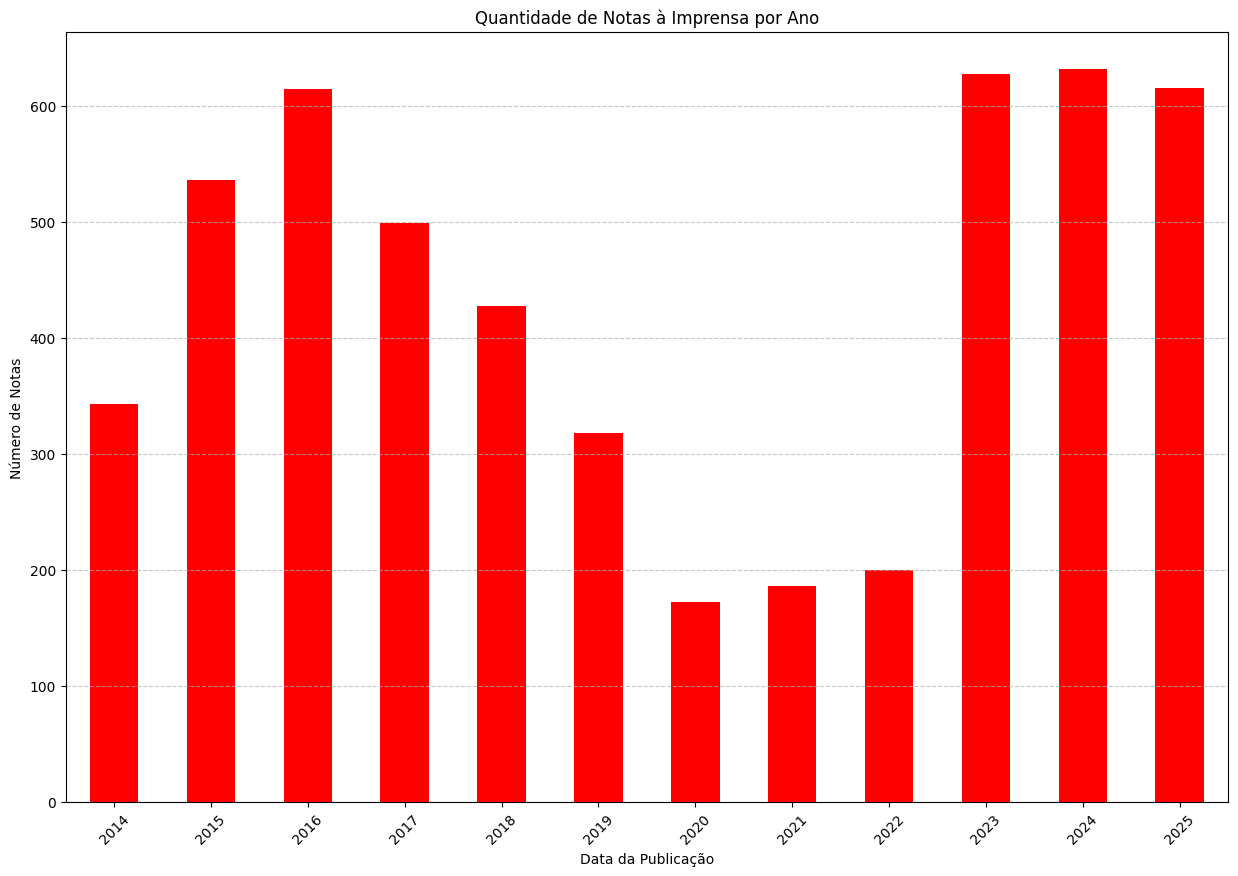

In [31]:
import matplotlib.pyplot as plt

# Criando o gráfico
plt.figure(figsize=(15, 10))
notas_por_ano.plot(kind='bar', color='red')

# Adicionando títulos e rótulos
plt.title('Quantidade de Notas à Imprensa por Ano')
plt.xlabel('Data da Publicação')
plt.ylabel('Número de Notas')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

## Análise da palavras chave

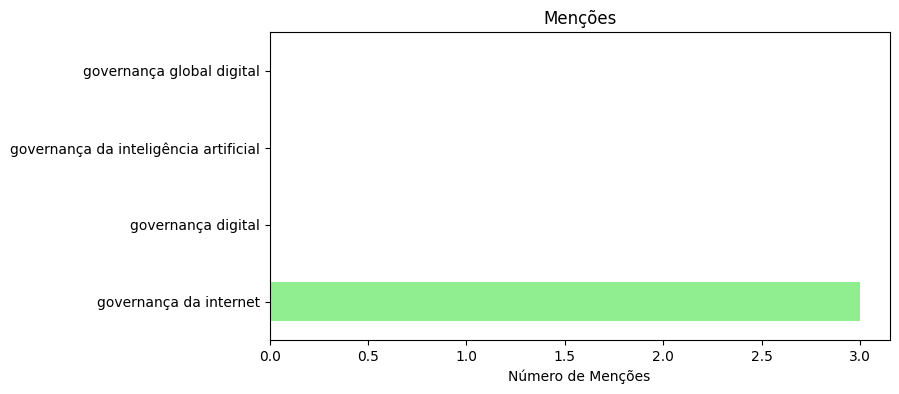

In [32]:
termos = ['governança digital', 'governança da internet', 'governança da inteligência artificial', 'governança global digital']
frequencia = {}

for termo in termos:
    # Conta em quantos títulos a palavra aparece
    frequencia[termo] = df['texto_completo'].str.contains(termo, case=False).sum()

# Converter para série para facilitar a plotagem
ser_freq = pd.Series(frequencia)

plt.figure(figsize=(8, 4))
ser_freq.sort_values(ascending=False).plot(kind='barh', color='lightgreen')
plt.title('Menções')
plt.xlabel('Número de Menções')
plt.show()

In [33]:
df_customizado = df[["autoria","titulo",
       "data_atualizado", "horario_atualizado", "link", "paragrafos", "texto_completo","data_dt", "hora_int", "qtd_paragrafos", "tamanho_texto"]]
df_customizado

,autoria,titulo,data_atualizado,horario_atualizado,link,paragrafos,texto_completo,data_dt,hora_int,qtd_paragrafos,tamanho_texto
0,NA,Calendário de eventos entre 11 e 19 de janeiro...,31/10/2022,17h22,https://www.gov.br/mre/pt-br/canais_atendiment...,"9 a 18/JAN – Nova York, EUA. Convenção Anual d...",calendário de eventos entre 11 e 19 de janeiro...,2014-01-10,17.0,0,244
1,NA,Conferência Internacional sobre Síria (Genebra...,31/10/2022,17h21,https://www.gov.br/mre/pt-br/canais_atendiment...,Os profissionais de imprensa interessados em p...,conferência internacional sobre síria (genebra...,2014-01-08,17.0,0,132
2,NA,Calendário de eventos entre 4 de janeiro e 12 ...,31/10/2022,17h21,https://www.gov.br/mre/pt-br/canais_atendiment...,4 a 11/JAN – Singapura. Visita a Singapura do ...,calendário de eventos entre 4 de janeiro e 12 ...,2014-01-03,18.0,0,310
3,NA,Atentados no Líbano,31/10/2022,17h21,https://www.gov.br/mre/pt-br/canais_atendiment...,O Governo brasileiro condena a série recente d...,atentados no líbano o governo brasileiro conde...,2014-01-02,10.0,0,80
4,NA,Calendário de eventos entre 1º e 9 de fevereir...,31/10/2022,17h22,https://www.gov.br/mre/pt-br/canais_atendiment...,"1º e 2/FEV – Melbourne, Austrália. Festival Mu...",calendário de eventos entre 1º e 9 de fevereir...,2014-01-31,18.0,0,85
...,...,...,...,...,...,...,...,...,...,...,...
5164,Ministério das Relações Exteriores,Acordo entre o Reino do Bahrein e o Estado de ...,NA,NA,https://www.gov.br/mre/pt-br/canais_atendiment...,O governo brasileiro recebeu com satisfação ...,acordo entre o reino do bahrein e o estado de ...,2020-09-12,18.0,0,257
5165,Ministério das Relações Exteriores,Declaração Conjunta sobre o Comércio de Etanol...,NA,NA,https://www.gov.br/mre/pt-br/canais_atendiment...,Brasil e Estados Unidos realizaram consultas s...,declaração conjunta sobre o comércio de etanol...,2020-09-11,23.0,0,890
5166,Ministério das Relações Exteriores,Representantes do regime ilegítimo da Venezuel...,NA,NA,https://www.gov.br/mre/pt-br/canais_atendiment...,"Na data de hoje, 4 de setembro de 2020, o Gove...",representantes do regime ilegítimo da venezuel...,2020-09-04,20.0,0,210
5167,Ministério das Relações Exteriores,Embargo indevido do Governo das Filipinas à ca...,NA,NA,https://www.gov.br/mre/pt-br/canais_atendiment...,"O governo da República das Filipinas impôs, ...",embargo indevido do governo das filipinas à ca...,2020-09-04,18.0,0,239


In [34]:
def buscar_termo(termo, onde='completo'):
    """
    Busca um termo nas notas do MRE.

    Parâmetros:
        termo (str): palavra ou expressão a buscar (não diferencia maiúsc/minúsc)
        onde (str): 'titulo', 'texto' ou 'completo' (título + corpo)

    Retorna:
        DataFrame com as notas que contêm o termo
    """
    coluna = {
        'titulo': 'titulo',
        'texto': 'texto',
        'completo': 'texto_completo',
    }[onde]

    # busca case-insensitive; na=False ignora valores faltantes
    mascara = df_customizado[coluna].str.contains(termo, case=False, na=False, regex=False)
    resultado = df_customizado[mascara].sort_values('data_dt', ascending=False)

    print(f"🔎 Termo: '{termo}'  |  Onde: {onde}")
    print(f"📌 Notas encontradas: {len(resultado)} de {len(df_customizado)} ({len(resultado)/len(df_customizado)*100:.1f}%)")
    print("-" * 60)

    for _, row in resultado.iterrows():
        data_str = row['data_dt'].strftime('%d/%m/%Y') if pd.notna(row['data_dt']) else '?'
        print(f"  • [{data_str}] {row['titulo']}")

    return resultado

### Governança

In [39]:
buscar_termo('governança', onde='completo')

🔎 Termo: 'governança'  |  Onde: completo
📌 Notas encontradas: 12 de 5169 (0.2%)
------------------------------------------------------------
  • [06/07/2025] Declaração dos Líderes do BRICS sobre Governança Global da Inteligência Artificial
  • [19/11/2024] Declaração sobre Infraestrutura Pública Digital, IA e Dados para Governança – Comunicado conjunto de Brasil, África do Sul e Índia
  • [25/09/2024] Segunda reunião de ministros das Relações Exteriores do G20 – Chamado à Ação sobre a Reforma da Governança Global - Nova York, 25 de setembro
  • [11/08/2017] Calendário de eventos entre 14 de agosto e 20 de agosto de 2017
  • [08/07/2017] Declaração dos Lideres do G20 – Moldando um Mundo Interconectado
  • [08/07/2016] Declaração por ocasião do lançamento da “Parceria para Governo Aberto”
  • [04/07/2016] Atos assinados por ocasião da visita ao Brasil do Primeiro-Ministro do Canadá, Stephen Harper – Brasília, 8 de agosto de 2011
  • [04/09/2015] Calendário de eventos entre 6 e 12 de set

,autoria,titulo,data_atualizado,horario_atualizado,link,paragrafos,texto_completo,data_dt,hora_int,qtd_paragrafos,tamanho_texto
4270,Ministério das Relações Exteriores,Declaração dos Líderes do BRICS sobre Governan...,NA,NA,https://www.gov.br/mre/pt-br/canais_atendiment...,.,declaração dos líderes do brics sobre governan...,2025-07-06,20.0,0,1
3774,Ministério das Relações Exteriores,Declaração sobre Infraestrutura Pública Digita...,NA,NA,https://www.gov.br/mre/pt-br/canais_atendiment...,Declaração sobre Infraestrutura Pública Dig...,declaração sobre infraestrutura pública digita...,2024-11-19,17.0,0,158
3713,Ministério das Relações Exteriores,Segunda reunião de ministros das Relações Exte...,NA,NA,https://www.gov.br/mre/pt-br/canais_atendiment...,"Foi realizada em 25 de setembro, em Nova York,...",segunda reunião de ministros das relações exte...,2024-09-25,11.0,0,638
1783,NA,Calendário de eventos entre 14 de agosto e 20 ...,18/08/2017,21h00,https://www.gov.br/mre/pt-br/canais_atendiment...,14 a 16/AGO – Brasília. Oficina de Trabalho Re...,calendário de eventos entre 14 de agosto e 20 ...,2017-08-11,20.0,0,185
1732,NA,Declaração dos Lideres do G20 – Moldando um Mu...,14/11/2017,15h23,https://www.gov.br/mre/pt-br/canais_atendiment...,"PreâmbuloNós, os Líderes do G20, reunimo-nos e...",declaração dos lideres do g20 – moldando um mu...,2017-07-08,20.0,0,41754
1228,NA,Declaração por ocasião do lançamento da “Parce...,31/10/2022,17h31,https://www.gov.br/mre/pt-br/canais_atendiment...,"Como membros da Parceria Governo Aberto, compr...",declaração por ocasião do lançamento da “parce...,2016-07-08,19.0,0,272
1157,NA,Atos assinados por ocasião da visita ao Brasil...,31/10/2022,17h30,https://www.gov.br/mre/pt-br/canais_atendiment...,1 - MEMORANDO DE ENTENDIMENTO ENTRE O GOVERNO ...,atos assinados por ocasião da visita ao brasil...,2016-07-04,18.0,0,209
721,NA,Calendário de eventos entre 6 e 12 de setembro...,01/10/2015,21h05,https://www.gov.br/mre/pt-br/canais_atendiment...,"06/SET – Ancara, Turquia. Lançamento da Inicia...",calendário de eventos entre 6 e 12 de setembro...,2015-09-04,21.0,0,2741
696,NA,Calendário de eventos entre 30 de agosto e 5 d...,07/10/2015,18h05,https://www.gov.br/mre/pt-br/canais_atendiment...,"31/AGO a 02/SET – Assunção, Paraguai. Reunião ...",calendário de eventos entre 30 de agosto e 5 d...,2015-08-29,21.0,0,2230
630,NA,Adoção da Resolução sobre a Incompatibilidade ...,03/07/2015,16h09,https://www.gov.br/mre/pt-br/canais_atendiment...,"O Governo brasileiro registra, com satisfação,...",adoção da resolução sobre a incompatibilidade ...,2015-07-03,14.0,0,629


### Governança digital

In [45]:
buscar_termo('governança global digital', onde='completo')

🔎 Termo: 'governança global digital'  |  Onde: completo
📌 Notas encontradas: 0 de 5169 (0.0%)
------------------------------------------------------------


,autoria,titulo,data_atualizado,horario_atualizado,link,paragrafos,texto_completo,data_dt,hora_int,qtd_paragrafos,tamanho_texto


In [52]:
buscar_termo('digital', onde='completo')
teste = buscar_termo('digital', onde='completo')

🔎 Termo: 'digital'  |  Onde: completo
📌 Notas encontradas: 27 de 5169 (0.5%)
------------------------------------------------------------
  • [26/11/2025] I Diálogo Digital Brasil-Índia - Brasília, 26 de novembro de 2025
  • [18/03/2025] Seminário sobre economia de dados e desenvolvimento nacional – Nota Conjunta MRE/MDIC
  • [12/02/2025] Diálogo Digital Brasil – União Europeia – Comunicado Conjunto – Bruxelas, 12 de fevereiro
  • [09/02/2025] Participação do Ministro Mauro Vieira na Cúpula para Ação em Inteligência Artificial – Paris, 10 e 11 de fevereiro de 2025
  • [19/11/2024] Declaração sobre Infraestrutura Pública Digital, IA e Dados para Governança – Comunicado conjunto de Brasil, África do Sul e Índia
  • [17/07/2023] Declaração Conjunta sobre a Aliança Digital América Latina e Caribe - União Europeia
  • [06/03/2023] Conclusão das negociações do acordo sobre conservação e uso sustentável da biodiversidade marinha em áreas além da jurisdição nacional (BBNJ)
  • [21/01/2023] Vis

In [55]:
teste_quant = teste.count()
print (teste_quant)

autoria               27
titulo                27
data_atualizado       27
horario_atualizado    27
link                  27
paragrafos            27
texto_completo        27
data_dt               27
hora_int              27
qtd_paragrafos        27
tamanho_texto         27
dtype: int64


### Governança da Internet

In [42]:
buscar_termo('governança da internet', onde='completo')

🔎 Termo: 'governança da internet'  |  Onde: completo
📌 Notas encontradas: 3 de 5169 (0.1%)
------------------------------------------------------------
  • [04/09/2015] Calendário de eventos entre 6 e 12 de setembro de 2015
  • [29/08/2015] Calendário de eventos entre 30 de agosto e 5 de setembro de 2015
  • [15/07/2014] VI Cúpula BRICS – Declaração de Fortaleza – 15 de julho de 2014


,autoria,titulo,data_atualizado,horario_atualizado,link,paragrafos,texto_completo,data_dt,hora_int,qtd_paragrafos,tamanho_texto
721,NA,Calendário de eventos entre 6 e 12 de setembro...,01/10/2015,21h05,https://www.gov.br/mre/pt-br/canais_atendiment...,"06/SET – Ancara, Turquia. Lançamento da Inicia...",calendário de eventos entre 6 e 12 de setembro...,2015-09-04,21.0,0,2741
696,NA,Calendário de eventos entre 30 de agosto e 5 d...,07/10/2015,18h05,https://www.gov.br/mre/pt-br/canais_atendiment...,"31/AGO a 02/SET – Assunção, Paraguai. Reunião ...",calendário de eventos entre 30 de agosto e 5 d...,2015-08-29,21.0,0,2230
279,NA,VI Cúpula BRICS – Declaração de Fortaleza – 15...,31/10/2022,17h45,https://www.gov.br/mre/pt-br/canais_atendiment...,"1. Nós, os líderes da República Federativa do ...",vi cúpula brics – declaração de fortaleza – 15...,2014-07-15,14.0,0,57109


In [43]:
buscar_termo('governança global da internet', onde='completo')

🔎 Termo: 'governança global da internet'  |  Onde: completo
📌 Notas encontradas: 0 de 5169 (0.0%)
------------------------------------------------------------


,autoria,titulo,data_atualizado,horario_atualizado,link,paragrafos,texto_completo,data_dt,hora_int,qtd_paragrafos,tamanho_texto


In [49]:
buscar_termo('internet', onde='completo')

🔎 Termo: 'internet'  |  Onde: completo
📌 Notas encontradas: 14 de 5169 (0.3%)
------------------------------------------------------------
  • [24/10/2022] Nota conjunta do Ministério das Relações Exteriores, do Ministério das Comunicações e da Agência Nacional de Telecomunicações - Participação brasileira na Conferência de Plenipotenciários (PP-22) da União Internacional de Telecomunicações (UIT)
  • [29/06/2019] Declaração de Osaka dos Líderes do G20 para a Prevenção da Exploração da Internet para o Terrorismo e o Extremismo Violento Conducente ao Terrorismo (EVCT)
  • [20/05/2019] Solicitação de atribuição de domínio de primeiro nível “.Amazon”
  • [18/04/2019] Solicitação de atribuição de domínio de primeiro nível “.Amazon”
  • [11/03/2019] Solicitação de atribuição do nome de domínio de primeiro nível “.Amazon”
  • [26/09/2018] Calendário de eventos entre 21 e 28 de setembro de 2018
  • [11/08/2017] Calendário de eventos entre 14 de agosto e 20 de agosto de 2017
  • [18/03/2017] L

,autoria,titulo,data_atualizado,horario_atualizado,link,paragrafos,texto_completo,data_dt,hora_int,qtd_paragrafos,tamanho_texto
2617,Ministério das Relações Exteriores,Nota conjunta do Ministério das Relações Exter...,NA,NA,https://www.gov.br/mre/pt-br/canais_atendiment...,"Entre os dias 26 de setembro e 14 de outubro, ...",nota conjunta do ministério das relações exter...,2022-10-24,11.0,0,460
4889,Ministério das Relações Exteriores,Declaração de Osaka dos Líderes do G20 para a ...,NA,NA,https://www.gov.br/mre/pt-br/canais_atendiment...,"Como Líderes, uma de nossas maiores responsab...",declaração de osaka dos líderes do g20 para a ...,2019-06-29,14.0,0,479
4861,Ministério das Relações Exteriores,Solicitação de atribuição de domínio de primei...,NA,NA,https://www.gov.br/mre/pt-br/canais_atendiment...,O Ministério das Relações Exteriores lament...,solicitação de atribuição de domínio de primei...,2019-05-20,19.0,0,379
4828,Ministério das Relações Exteriores,Solicitação de atribuição de domínio de primei...,NA,NA,https://www.gov.br/mre/pt-br/canais_atendiment...,O Ministério das Relações Exteriores foi in...,solicitação de atribuição de domínio de primei...,2019-04-18,22.0,0,379
4795,Ministério das Relações Exteriores,Solicitação de atribuição do nome de domínio d...,NA,NA,https://www.gov.br/mre/pt-br/canais_atendiment...,"Em 10 de março, o Conselho Diretor da Corpora...",solicitação de atribuição do nome de domínio d...,2019-03-11,16.0,0,704
4592,Ministério das Relações Exteriores,Calendário de eventos entre 21 e 28 de setembr...,NA,NA,https://www.gov.br/mre/pt-br/canais_atendiment...,"27/AGO a 21/SET (Continuação) – Genebra, Sui...",calendário de eventos entre 21 e 28 de setembr...,2018-09-26,20.0,0,3074
1783,NA,Calendário de eventos entre 14 de agosto e 20 ...,18/08/2017,21h00,https://www.gov.br/mre/pt-br/canais_atendiment...,14 a 16/AGO – Brasília. Oficina de Trabalho Re...,calendário de eventos entre 14 de agosto e 20 ...,2017-08-11,20.0,0,185
1579,NA,Lançamento do Satélite Geoestacionário de Defe...,21/03/2017,15h28,https://www.gov.br/mre/pt-br/canais_atendiment...,"No próximo dia 21 de março, será lançado, do C...",lançamento do satélite geoestacionário de defe...,2017-03-18,13.0,0,497
1552,NA,Calendário de eventos entre 13 de fevereiro e ...,10/02/2017,21h50,https://www.gov.br/mre/pt-br/canais_atendiment...,"12/FEV a 14/FEV – Dubai, Emirados Árabes. Semi...",calendário de eventos entre 13 de fevereiro e ...,2017-02-10,21.0,0,2736
1377,NA,Visita do Presidente da República ao Paraguai ...,04/10/2016,15h43,https://www.gov.br/mre/pt-br/canais_atendiment...,MEMORANDO DE ENTENDIMENTO ENTRE O GOVERNO DA R...,visita do presidente da república ao paraguai ...,2016-10-04,15.0,0,5294


### Governança de IA

In [48]:
buscar_termo('governança global da inteligência artificial', onde='completo')

🔎 Termo: 'governança global da inteligência artificial'  |  Onde: completo
📌 Notas encontradas: 1 de 5169 (0.0%)
------------------------------------------------------------
  • [06/07/2025] Declaração dos Líderes do BRICS sobre Governança Global da Inteligência Artificial


,autoria,titulo,data_atualizado,horario_atualizado,link,paragrafos,texto_completo,data_dt,hora_int,qtd_paragrafos,tamanho_texto
4270,Ministério das Relações Exteriores,Declaração dos Líderes do BRICS sobre Governan...,NA,NA,https://www.gov.br/mre/pt-br/canais_atendiment...,.,declaração dos líderes do brics sobre governan...,2025-07-06,20.0,0,1


In [50]:
buscar_termo('inteligência artificial', onde='completo')

🔎 Termo: 'inteligência artificial'  |  Onde: completo
📌 Notas encontradas: 3 de 5169 (0.1%)
------------------------------------------------------------
  • [06/11/2025] Seleção de brasileiro ao Prêmio da UNESCO para Pesquisa Científica sobre Ética na Inteligência Artificial
  • [06/07/2025] Declaração dos Líderes do BRICS sobre Governança Global da Inteligência Artificial
  • [09/02/2025] Participação do Ministro Mauro Vieira na Cúpula para Ação em Inteligência Artificial – Paris, 10 e 11 de fevereiro de 2025


,autoria,titulo,data_atualizado,horario_atualizado,link,paragrafos,texto_completo,data_dt,hora_int,qtd_paragrafos,tamanho_texto
2214,Ministério das Relações Exteriores,Seleção de brasileiro ao Prêmio da UNESCO para...,NA,NA,https://www.gov.br/mre/pt-br/canais_atendiment...,"O governo brasileiro recebeu, com grande satis...",seleção de brasileiro ao prêmio da unesco para...,2025-11-06,12.0,0,600
4270,Ministério das Relações Exteriores,Declaração dos Líderes do BRICS sobre Governan...,NA,NA,https://www.gov.br/mre/pt-br/canais_atendiment...,.,declaração dos líderes do brics sobre governan...,2025-07-06,20.0,0,1
4062,Ministério das Relações Exteriores,Participação do Ministro Mauro Vieira na Cúpul...,NA,NA,https://www.gov.br/mre/pt-br/canais_atendiment...,O Ministro Mauro Vieira chefiará a delegaçã...,participação do ministro mauro vieira na cúpul...,2025-02-09,14.0,0,463


## Palavras mais frequentes

Top 20 palavras nos TÍTULOS:
  brasil                    1329
  visita                    714
  conjunta                  559
  república                 521
  ministro                  493
  relações                  463
  exteriores                426
  brasília                  418
  presidente                405
  reunião                   387
  concessão                 384
  embaixador                381
  agrément                  370
  ministério                323
  declaração                293
  eventos                   292
  calendário                284
  ocasião                   237
  cúpula                    226
  comunicado                219


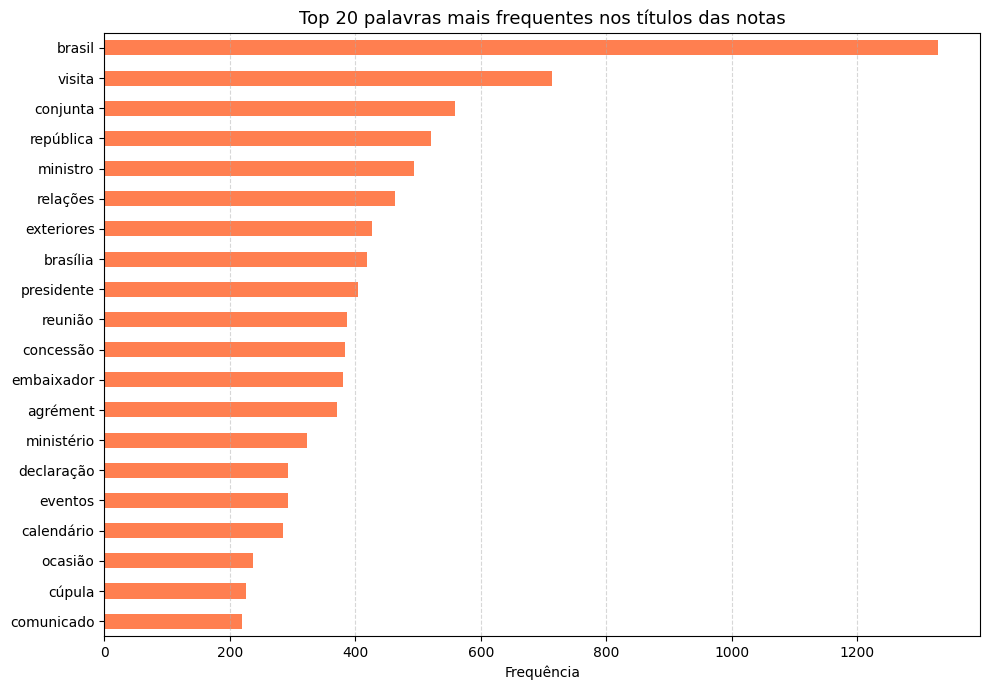

In [36]:
import re
from collections import Counter

# Stopwords em português (lista pequena, suficiente para começar)
STOPWORDS_PT = {
    'a', 'o', 'as', 'os', 'um', 'uma', 'uns', 'umas',
    'de', 'do', 'da', 'dos', 'das', 'em', 'no', 'na', 'nos', 'nas',
    'e', 'ou', 'mas', 'que', 'se', 'por', 'para', 'com', 'sem',
    'à', 'ao', 'às', 'aos', 'pelo', 'pela', 'pelos', 'pelas',
    'é', 'são', 'foi', 'ser', 'estar', 'tem', 'ter', 'há',
    'sobre', 'entre', 'até', 'após', 'pela', 'pelo',
    'sua', 'seu', 'suas', 'seus', 'este', 'esta', 'isso', 'esse', 'essa',
    'nº', 'n°', 'nota', 'notas', 'imprensa',  # específicas do contexto
}


def palavras_mais_frequentes(serie_texto, top_n=20, min_tamanho=4):
    """Conta as palavras mais frequentes em uma coluna de texto."""
    todas_palavras = []
    for texto in serie_texto.dropna():
        # \w+ pega sequências de letras/números; flags re.UNICODE pra acentos
        palavras = re.findall(r'\b[a-záàâãéêíóôõúüç]+\b', texto.lower(), flags=re.UNICODE)
        palavras = [p for p in palavras if p not in STOPWORDS_PT and len(p) >= min_tamanho]
        todas_palavras.extend(palavras)
    return Counter(todas_palavras).most_common(top_n)


top_palavras = palavras_mais_frequentes(df['titulo'], top_n=20)
print("Top 20 palavras nos TÍTULOS:")
for palavra, contagem in top_palavras:
    print(f"  {palavra:25s} {contagem}")

# Gráfico
serie = pd.Series(dict(top_palavras)).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(10, 7))
serie.plot(kind='barh', ax=ax, color='coral')
ax.set_title('Top 20 palavras mais frequentes nos títulos das notas', fontsize=13)
ax.set_xlabel('Frequência')
ax.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Nuvem de palavras

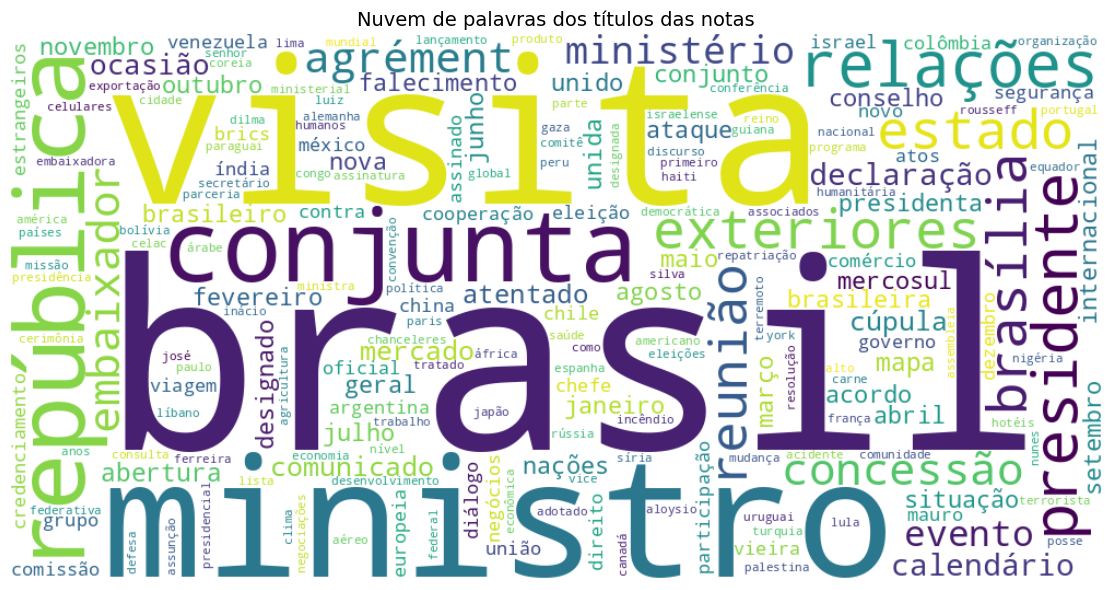

In [38]:
from wordcloud import WordCloud

# Junta todos os títulos em um único texto gigante
texto_titulos = ' '.join(df['titulo'].dropna()).lower()

# Remove stopwords usando o set já definido
wc = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    stopwords=STOPWORDS_PT,
    colormap='viridis',
    min_word_length=4,
    collocations=False,  # evita repetir bigramas
).generate(texto_titulos)

fig, ax = plt.subplots(figsize=(13, 6))
ax.imshow(wc, interpolation='bilinear')
ax.axis('off')
ax.set_title('Nuvem de palavras dos títulos das notas', fontsize=14)
plt.tight_layout()
plt.show()
